<a href="https://colab.research.google.com/github/KeyzaNadineKusumaRamadani/tugasKKA/blob/main/Studi_kasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('data_penjualan_lengkap.csv')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,98200,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,35130,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,21170,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,43840,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,26250,3640000.0


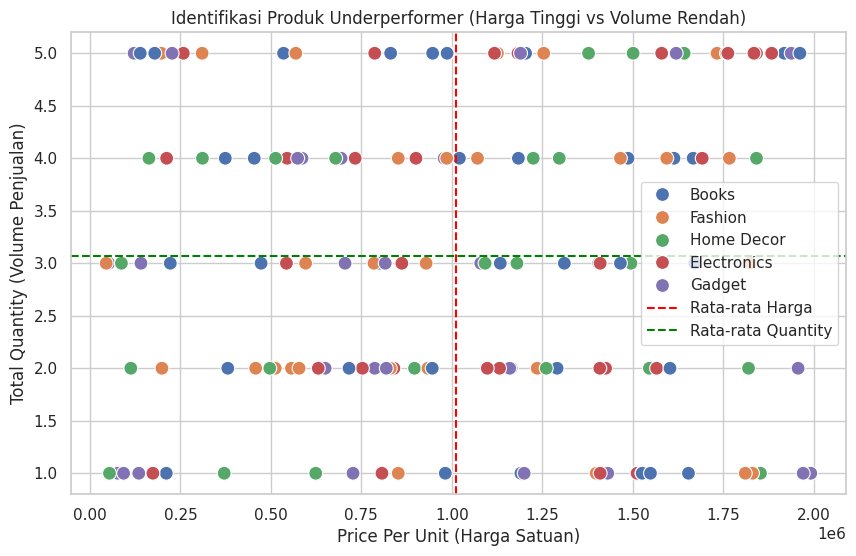

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Price_Per_Unit', y='Quantity', hue='Product_Category', s=100)

plt.axvline(df['Price_Per_Unit'].mean(), color='red', linestyle='--', label='Rata-rata Harga')
plt.axhline(df['Quantity'].mean(), color='green', linestyle='--', label='Rata-rata Quantity')

plt.title('Identifikasi Produk Underperformer (Harga Tinggi vs Volume Rendah)')
plt.xlabel('Price Per Unit (Harga Satuan)')
plt.ylabel('Total Quantity (Volume Penjualan)')
plt.legend()
plt.show()

In [27]:
avg_price = df['Price_Per_Unit'].mean()
avg_qty = df['Quantity'].mean()

underperformer = df[(df['Price_Per_Unit'] > avg_price) & (df['Quantity'] < avg_qty)]
print("Daftar Produk Underperformer:")
print(underperformer[['Order_ID', 'Product_Category', 'Price_Per_Unit', 'Quantity']])

Daftar Produk Underperformer:
     Order_ID Product_Category  Price_Per_Unit  Quantity
4        1005       Home Decor       1820000.0         2
7        1008           Gadget       1431000.0         1
10       1011      Electronics       1425000.0         2
16       1017           Gadget       1164000.0         2
17       1018       Home Decor       1495000.0         3
18       1019       Home Decor       1546000.0         2
19       1020            Books       1654000.0         1
26       1027           Gadget       1080000.0         3
29       1030           Gadget       1957000.0         2
30       1031            Books       1134000.0         3
33       1034       Home Decor       1853000.0         1
36       1037           Gadget       1406000.0         3
41       1042           Gadget       1992000.0         1
42       1043      Electronics       1409000.0         2
52       1053            Books       1311000.0         3
75       1076      Electronics       1566000.0         2
7

In [28]:
import pandas as pd
from datetime import datetime

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                                   # Frequency
    'Total_Sales': 'sum'                                   # Monetary
})

rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Total_Sales': 'Monetary'
}, inplace=True)

print("Tabel RFM Pelanggan:")
print(rfm.sort_values(by='Monetary', ascending=False).head(10))

Tabel RFM Pelanggan:
            Recency  Frequency    Monetary
CustomerID                                
5015             21          6  27741000.0
5008             15          6  22350000.0
5035             53          6  22066000.0
5014             54          6  20797000.0
5044             18          7  20631000.0
5004            196          3  20268000.0
5025             75          4  19063000.0
5042              1          4  18754000.0
5023            114          3  17203000.0
5034            137          2  16895000.0


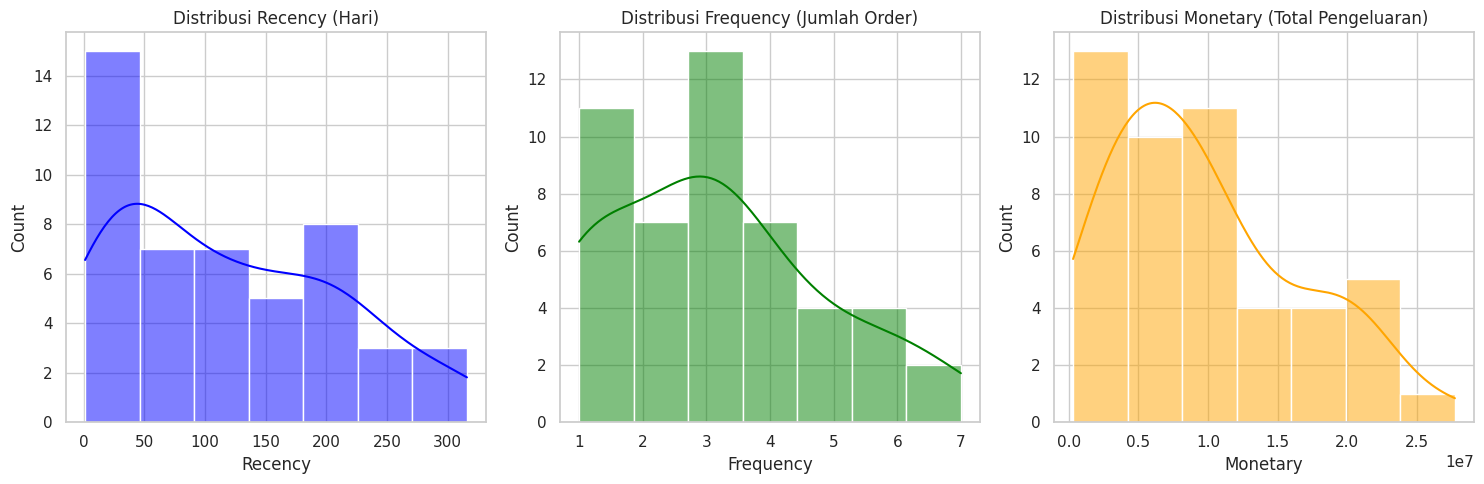

In [29]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, color='blue')
plt.title('Distribusi Recency (Hari)')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True, color='green')
plt.title('Distribusi Frequency (Jumlah Order)')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], kde=True, color='orange')
plt.title('Distribusi Monetary (Total Pengeluaran)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1008/2410886626.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


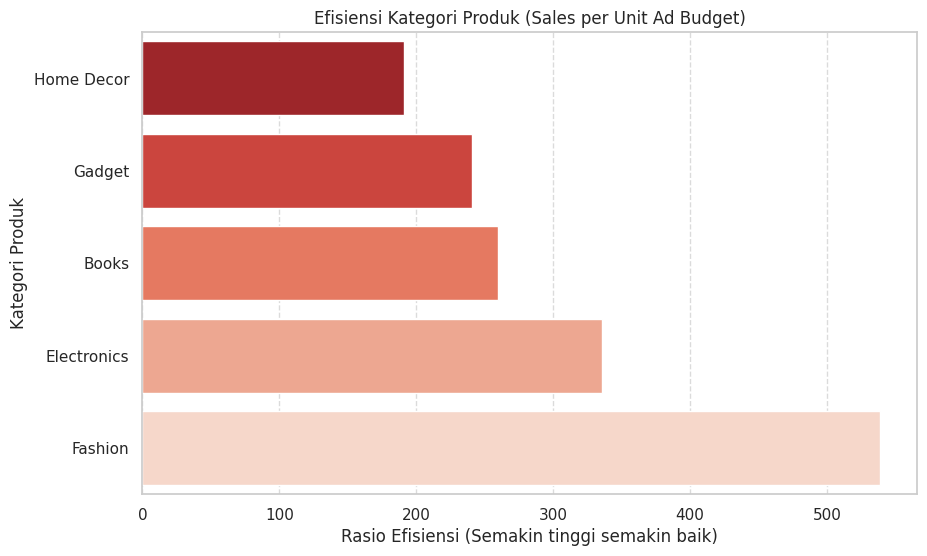

Tabel Analisis Efisiensi:
  Product_Category  Total_Sales  Ad_Budget  Efficiency_Ratio
4       Home Decor   73457000.0     383903        191.342605
3           Gadget   71102000.0     295203        240.857986
0            Books  112934000.0     435079        259.571250
1      Electronics  114095000.0     339607        335.961862
2          Fashion   96251000.0     178536        539.112560


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

category_analysis = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
}).reset_index()

category_analysis['Efficiency_Ratio'] = category_analysis['Total_Sales'] / category_analysis['Ad_Budget']

category_analysis = category_analysis.sort_values(by='Efficiency_Ratio', ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Reds_r", len(category_analysis)) # Warna merah untuk yang kurang efisien

sns.barplot(
    data=category_analysis,
    x='Efficiency_Ratio',
    y='Product_Category',
    palette=colors
)

plt.title('Efisiensi Kategori Produk (Sales per Unit Ad Budget)')
plt.xlabel('Rasio Efisiensi (Semakin tinggi semakin baik)')
plt.ylabel('Kategori Produk')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print("Tabel Analisis Efisiensi:")
print(category_analysis[['Product_Category', 'Total_Sales', 'Ad_Budget', 'Efficiency_Ratio']])

Median Ad_Budget: Rp 4,005
------------------------------
Rata-rata Penjualan (Iklan Tinggi): Rp 3,102,893
Rata-rata Penjualan (Iklan Rendah): Rp 3,134,960
Perbedaan: -1.02%


/tmp/ipykernel_1008/1888109575.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Iklan Rendah', 'Iklan Tinggi'], y=[mean_sales_low, mean_sales_high], palette='coolwarm')


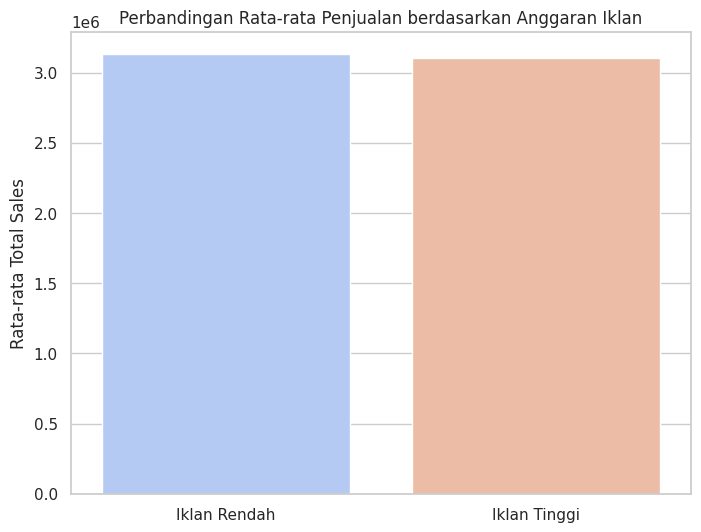

In [31]:
import pandas as pd

median_ad = df['Ad_Budget'].median()
high_ad = df[df['Ad_Budget'] > median_ad]
low_ad = df[df['Ad_Budget'] <= median_ad]
mean_sales_high = high_ad['Total_Sales'].mean()
mean_sales_low = low_ad['Total_Sales'].mean()
diff_percentage = ((mean_sales_high - mean_sales_low) / mean_sales_low) * 100

print(f"Median Ad_Budget: Rp {median_ad:,.0f}")
print("-" * 30)
print(f"Rata-rata Penjualan (Iklan Tinggi): Rp {mean_sales_high:,.0f}")
print(f"Rata-rata Penjualan (Iklan Rendah): Rp {mean_sales_low:,.0f}")
print(f"Perbedaan: {diff_percentage:.2f}%")

plt.figure(figsize=(8, 6))
sns.barplot(x=['Iklan Rendah', 'Iklan Tinggi'], y=[mean_sales_low, mean_sales_high], palette='coolwarm')
plt.title('Perbandingan Rata-rata Penjualan berdasarkan Anggaran Iklan')
plt.ylabel('Rata-rata Total Sales')
plt.show()

In [34]:
import datetime as dt

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                                   # Frequency
    'Total_Sales': 'sum'                                   # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]) # Recency kecil = Skor besar
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Group'] = rfm.R_Score.astype(str) + rfm.F_Score.astype(str) + rfm.M_Score.astype(str)

In [33]:
print(rfm[rfm['RFM_Group'] == '555'].head())

print(rfm.groupby('RFM_Group').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1))

            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5008             15          6  22350000.0       5       5       5       555
5015             21          6  27741000.0       5       5       5       555
5044             18          7  20631000.0       5       5       5       555
          Recency Frequency    Monetary      
             mean      mean        mean count
RFM_Group                                    
111         263.7       1.0   1862333.3     3
112         235.0       1.0   4192500.0     2
113         307.5       1.0   7197500.0     2
133         223.0       3.0   6912500.0     2
143         213.0       4.0   8562000.0     1
211         174.0       1.0   1550000.0     1
212         136.0       1.0   5630000.0     1
221         171.0       2.0   2027000.0     1
224         189.0       2.0  11205000.0     1
225         137.0       2.0  16895000.0     1
232         201.0

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Ad_Budget']] # Fitur
y = df['Total_Sales'] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")

Koefisien Iklan: 15.90271674211211
Akurasi Model (R2 Score): -0.09282624326656141


In [ ]:
import datetime as dt

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LinearRegression